In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
file_path = "Week3_Clean_Product_Data_Final.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (242, 11)


,Record_ID,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL
0,1.0,Nike,Nike Shox TL Men's Shoes,Footwear,Lifestyle,Men,15995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
1,2.0,Nike,Nike Zoom Vomero 5 Men's Shoes,Footwear,Lifestyle,Men,14995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
2,3.0,Nike,Nike Air Max 95 Older Bubble Men's Shoes,Footwear,Lifestyle,Men,16995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
3,4.0,Nike,Nike Ava X Mesh Men's Shoes,Footwear,Lifestyle,Men,10795.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
4,5.0,Nike,Nike Air Max Dn8 Men's Shoes,Footwear,Lifestyle,Men,17495.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 242
Columns: 11

Column Names:
['Record_ID', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']

Missing Values:
Record_ID                0
Brand                    0
Product_Name             0
Category                 0
Sub_Category             0
Gender                   0
Selling_Price_INR       53
Original_Price_INR     204
Price_Segment           53
Data_Collected_Date      0
Source_URL               0
dtype: int64


In [8]:
target = "Selling_Price_INR"

features = [
    "Brand",
    "Category",
    "Sub_Category",
    "Gender"
]

model_data = df.dropna(subset=[target]).copy()

X = model_data[features]
y = model_data[target]

print("Total records:", len(df))
print("Records with selling price:", len(model_data))
print("Records with missing selling price:", df[target].isnull().sum())

Total records: 242
Records with selling price: 189
Records with missing selling price: 53


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 151
Testing records: 38


In [11]:
categorical_features = [
    "Brand",
    "Category",
    "Sub_Category",
    "Gender"
]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [12]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R²  :", round(lr_r2, 4))

Linear Regression
MAE : 1871.97
RMSE: 2758.83
R²  : 0.6365


In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=400,
                max_depth=8,
                min_samples_leaf=2,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
MAE : 1620.62
RMSE: 2435.98
R²  : 0.7166


In [14]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=150,
                max_depth=2,
                learning_rate=0.05,
                loss="huber",
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting
MAE : 1729.24
RMSE: 2514.06
R²  : 0.6981


In [15]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

results = results.round(2)

print(results)

               Model      MAE     RMSE  R2 Score
0  Linear Regression  1871.97  2758.83      0.64
1      Random Forest  1620.62  2435.98      0.72
2  Gradient Boosting  1729.24  2514.06      0.70


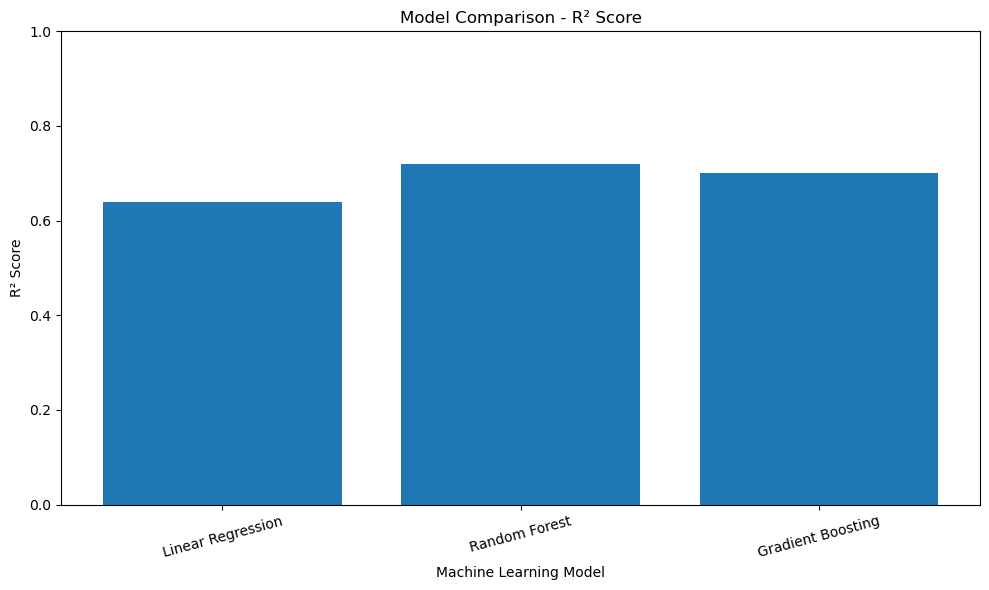

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

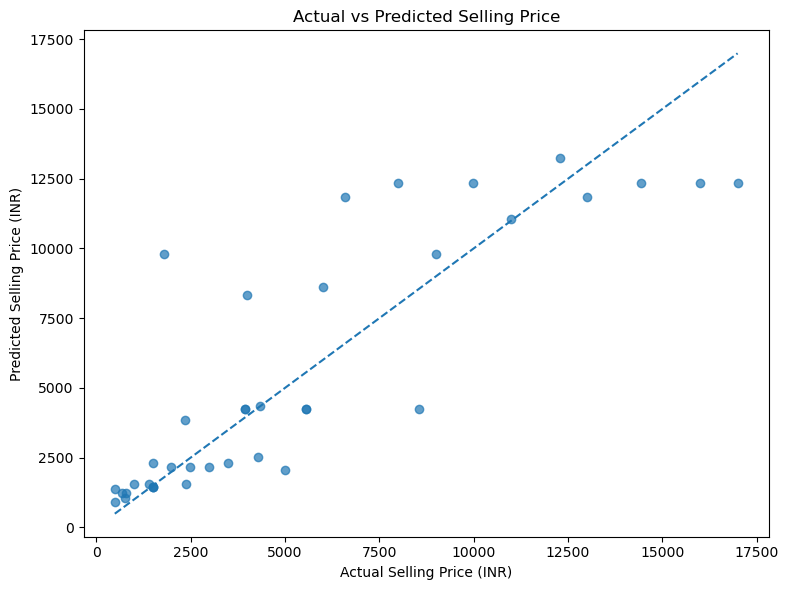

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Selling Price")
plt.xlabel("Actual Selling Price (INR)")
plt.ylabel("Predicted Selling Price (INR)")

plt.tight_layout()
plt.show()

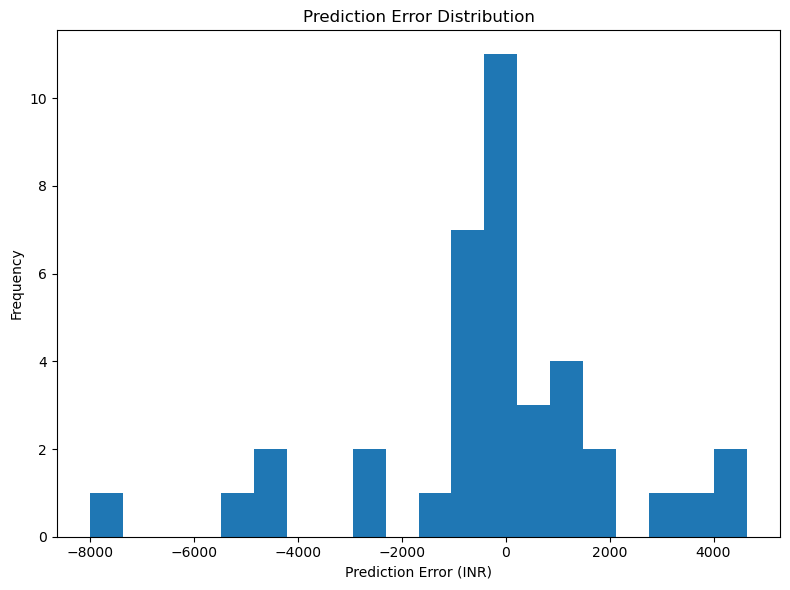

In [18]:
errors = y_test - rf_pred

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=20)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [19]:
missing_price_data = df[
    df["Selling_Price_INR"].isnull()
].copy()

print("Missing price records:", len(missing_price_data))

Missing price records: 53


In [20]:
missing_price_data["Predicted_Selling_Price_INR"] = rf_model.predict(
    missing_price_data[features]
)

missing_price_data["Predicted_Selling_Price_INR"] = (
    missing_price_data["Predicted_Selling_Price_INR"]
    .round(2)
)

missing_price_data.head(20)

,Record_ID,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL,Predicted_Selling_Price_INR
41,42.0,Nike,Nike Structure 26 Men's Road Running Shoes,Footwear,Running,Men,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,12623.51
42,43.0,Nike,Nike Domain 3 Low Men's Cricket Shoes,Footwear,Cricket,Men,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,12264.62
44,45.0,Nike,Nike Air Max 95 Women's Shoes,Footwear,Lifestyle,Women,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,11365.85
45,46.0,Nike,Nike Air Max 1 Women's Shoes,Footwear,Lifestyle,Women,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,11365.85
46,47.0,Nike,Nike Air Max 1 Men's Shoes,Footwear,Lifestyle,Men,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,12348.80
47,48.0,Nike,Nike Air Max 270 Men's Shoes,Footwear,Lifestyle,Men,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,12348.80
48,49.0,Nike,Nike Air Max 270 Women's Shoes,Footwear,Lifestyle,Women,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,11365.85
49,50.0,Nike,Nike Shox TL Women's Shoes,Footwear,Lifestyle,Women,NaN,NaN,NaN,2026-08-12,https://www.nike.in/,11365.85
69,70.0,adidas,BaseNew Shoes - Brown,Footwear,Lifestyle,Unspecified,NaN,NaN,NaN,2026-08-12,https://www.adidas.co.in/,10631.28
70,71.0,adidas,Stan Smith Shoes,Footwear,Originals,Unspecified,NaN,NaN,NaN,2026-08-12,https://www.adidas.co.in/,11068.27


In [21]:
prediction_results = missing_price_data[
    [
        "Record_ID",
        "Brand",
        "Product_Name",
        "Category",
        "Sub_Category",
        "Gender",
        "Predicted_Selling_Price_INR"
    ]
].copy()

prediction_results

,Record_ID,Brand,Product_Name,Category,Sub_Category,Gender,Predicted_Selling_Price_INR
41,42.0,Nike,Nike Structure 26 Men's Road Running Shoes,Footwear,Running,Men,12623.51
42,43.0,Nike,Nike Domain 3 Low Men's Cricket Shoes,Footwear,Cricket,Men,12264.62
44,45.0,Nike,Nike Air Max 95 Women's Shoes,Footwear,Lifestyle,Women,11365.85
45,46.0,Nike,Nike Air Max 1 Women's Shoes,Footwear,Lifestyle,Women,11365.85
46,47.0,Nike,Nike Air Max 1 Men's Shoes,Footwear,Lifestyle,Men,12348.80
47,48.0,Nike,Nike Air Max 270 Men's Shoes,Footwear,Lifestyle,Men,12348.80
48,49.0,Nike,Nike Air Max 270 Women's Shoes,Footwear,Lifestyle,Women,11365.85
49,50.0,Nike,Nike Shox TL Women's Shoes,Footwear,Lifestyle,Women,11365.85
69,70.0,adidas,BaseNew Shoes - Brown,Footwear,Lifestyle,Unspecified,10631.28
70,71.0,adidas,Stan Smith Shoes,Footwear,Originals,Unspecified,11068.27


In [23]:
top_predictions = prediction_results.sort_values(
    by="Predicted_Selling_Price_INR",
    ascending=False
)

top_predictions.head(10)

,Record_ID,Brand,Product_Name,Category,Sub_Category,Gender,Predicted_Selling_Price_INR
78,79.0,adidas,Men's Running Shoes,Footwear,Running,Men,13666.19
84,85.0,adidas,Men's Superstar Shoes,Footwear,Originals,Men,12711.75
83,84.0,adidas,Men's Campus Shoes,Footwear,Originals,Men,12711.75
82,83.0,adidas,Men's Samba Shoes,Footwear,Originals,Men,12711.75
81,82.0,adidas,Men's Original Shoes,Footwear,Originals,Men,12711.75
41,42.0,Nike,Nike Structure 26 Men's Road Running Shoes,Footwear,Running,Men,12623.51
46,47.0,Nike,Nike Air Max 1 Men's Shoes,Footwear,Lifestyle,Men,12348.80
47,48.0,Nike,Nike Air Max 270 Men's Shoes,Footwear,Lifestyle,Men,12348.80
80,81.0,adidas,Football Shoes for Men,Footwear,Football,Men,12328.56
42,43.0,Nike,Nike Domain 3 Low Men's Cricket Shoes,Footwear,Cricket,Men,12264.62


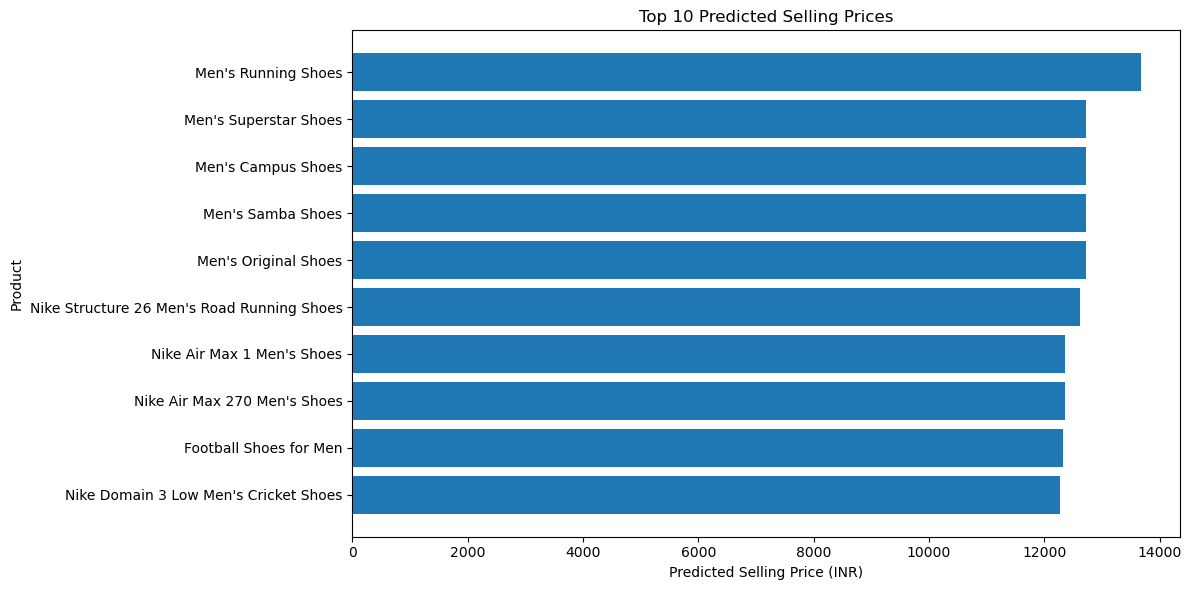

In [24]:
top_10 = top_predictions.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10["Product_Name"],
    top_10["Predicted_Selling_Price_INR"]
)

plt.title("Top 10 Predicted Selling Prices")
plt.xlabel("Predicted Selling Price (INR)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [25]:
prediction_results.to_csv(
    "Week4_Predicted_Selling_Prices.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [26]:
final_df = df.copy()

missing_mask = final_df["Selling_Price_INR"].isnull()

final_df.loc[
    missing_mask,
    "Predicted_Selling_Price_INR"
] = rf_model.predict(
    final_df.loc[missing_mask, features]
)

final_df["Predicted_Selling_Price_INR"] = (
    final_df["Predicted_Selling_Price_INR"].round(2)
)

final_df.head()

,Record_ID,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL,Predicted_Selling_Price_INR
0,1.0,Nike,Nike Shox TL Men's Shoes,Footwear,Lifestyle,Men,15995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/,NaN
1,2.0,Nike,Nike Zoom Vomero 5 Men's Shoes,Footwear,Lifestyle,Men,14995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/,NaN
2,3.0,Nike,Nike Air Max 95 Older Bubble Men's Shoes,Footwear,Lifestyle,Men,16995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/,NaN
3,4.0,Nike,Nike Ava X Mesh Men's Shoes,Footwear,Lifestyle,Men,10795.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/,NaN
4,5.0,Nike,Nike Air Max Dn8 Men's Shoes,Footwear,Lifestyle,Men,17495.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/,NaN


In [27]:
final_df.to_csv(
    "Week4_Final_Prediction_Dataset.csv",
    index=False
)

print("Final prediction dataset saved successfully!")

Final prediction dataset saved successfully!
